# Cross-checking `gw_response` against `lisagwresponse`

This notebook validates `gw_response`'s LISA single-link response against the
independently-developed [`lisagwresponse`](https://gitlab.in2p3.fr/lisa-simulation/gw-response)
package (J.-B. Bayle et al.), on two axes:

1. **Output**: do the two codes agree on the actual physics?
2. **Performance**: how does `gw_response`'s JAX/JIT-compiled approach
   compare to `lisagwresponse`'s time-domain, spline-interpolation approach?

**Requirement**: `lisagwresponse` is *not* a dependency of `gw_response` (not
even an optional one) — it's only needed to run this comparison notebook.
Install it yourself first:

```
pip install lisagwresponse
```


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.interpolate import make_interp_spline

import gw_response as gwr

try:
    from lisagwresponse import GalacticBinary
    from lisaconstants.indexing import LINKS
except ImportError as exc:
    raise ImportError(
        "This notebook needs the independent 'lisagwresponse' package, which "
        "is not a gw_response dependency. Install it with `pip install "
        "lisagwresponse` and re-run this notebook."
    ) from exc


/home/pieroni/.pyenv/versions/3.13.5/envs/ligo_sgwb/lib/python3.13/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


## 1. A common, frozen spacecraft geometry

`lisagwresponse` reads spacecraft positions and inter-satellite light-travel
times from an orbit file (or accepts constant/interpolated overrides).
`gw_response` computes them from its own analytical Keplerian model.

To compare the two codes' *response formulas* rather than two different
*orbit models*, we freeze `gw_response`'s LISA geometry at a single instant
and feed those exact numbers into `lisagwresponse` as constant spacecraft
positions and light-travel times. This isolates the comparison to the
single-link response physics itself.

In [2]:
lisa = gwr.LISA()
ps = gwr.PhysicalConstants()

t0_years = 0.0
positions = lisa.vertex_positions(t0_years)[0]  # (xyz=3, sat=3)
arms = lisa.detector_arms(t0_years)[0]  # (xyz=3, arm=6)
arm_labels = [12, 23, 31, 21, 32, 13]  # gw_response's arm ordering convention
arm_lengths = jnp.linalg.norm(arms, axis=0)
c = float(ps.light_speed)

print("Satellite positions [m] (columns = SC 1, 2, 3):")
print(positions)
print("\nArm lengths [m]:", arm_lengths)
print("Speed of light [m/s]: gw_response =", c, " lisaconstants =", 299792458.0)


Satellite positions [m] (columns = SC 1, 2, 3):
[[ 1.48876183e+11  1.49958715e+11  1.49958715e+11]
 [ 0.00000000e+00 -1.25000000e+09  1.25000000e+09]
 [-1.25000000e+09  6.25000000e+08  6.25000000e+08]]

Arm lengths [m]: [2.5e+09 2.5e+09 2.5e+09 2.5e+09 2.5e+09 2.5e+09]
Speed of light [m/s]: gw_response = 299792458.0  lisaconstants = 299792458.0


## 2. Feed the identical geometry into `lisagwresponse`

`lisagwresponse.GalacticBinary` (a `ResponseFromStrain` subclass) accepts
constant floats in place of orbit interpolants for `x`, `y`, `z`, `ltt`,
which is exactly what we need here.


In [ ]:
x = {sc: float(positions[0, sc - 1]) for sc in (1, 2, 3)}
y = {sc: float(positions[1, sc - 1]) for sc in (1, 2, 3)}
z = {sc: float(positions[2, sc - 1]) for sc in (1, 2, 3)}
ltt = {label: float(length) / c for label, length in zip(arm_labels, arm_lengths)}

# Sky position, in gw_response's (theta, phi) convention (colatitude, longitude).
theta0, phi0 = 1.1, 0.7

# lisagwresponse expects (right-ascension, declination) in the same Cartesian frame as 
# x, y, z. This requires convertng from gw_response's (theta, phi) to (ra, dec) using:
ra, dec = phi0, np.pi / 2 - theta0

# A generic monochromatic source: nonzero iota so both polarizations contribute (not 
# just an isolated plus- or cross-only special case). psi here is kept at 0 
A = 1e-21
iota, psi = 0.7, 0.0
dt = 1.0
n = 8192
df = 1.0 / (n * dt)
f0 = 41 * df  # an exact FFT bin: avoids spectral leakage in the comparison
t = np.arange(n) * dt  # NumPy: fed directly to lisagwresponse below

ref_source = GalacticBinary(
    A=A, f=f0, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
    ra=ra, dec=dec, x=x, y=y, z=z, ltt=ltt,
    orbits="unused.h5",  # not read, since x/y/z/ltt override it
    shift_sun="never",
)
ref_response = ref_source.compute_gw_response(t, LINKS)  # (n, 6)
ref_links = list(LINKS)
print("lisagwresponse output shape:", ref_response.shape, " link order:", LINKS)


lisagwresponse output shape: (8192, 6)  link order: [12 23 31 13 32 21]


## 3. Compute the same single-link response with `gw_response`

`Response.get_single_link_response_frozen_td` computes the raw per-link
Doppler response (FFT the waveform, multiply by the single-link transfer
function, IFFT back) -- the single-link sibling of
`get_response_frozen_td`, without its TDI/Michelson combination
step. Passing `wavevector_sign=-1.0, final_factor=1j * jnp.sqrt(2.0)`
gives the same physics in the convention that matches `lisagwresponse`
directly.

### The three convention differences

Two independently-developed codes for the same physics rarely share
*identical* normalization conventions. Comparing against `lisagwresponse`
surfaced exactly three, all well-understood and documented on
`get_single_link_response_frozen_td` -- **not fixed silently**, since they
reflect genuine convention choices, not bugs:

1. **Wavevector sign.** `gw_response`'s `unit_vec(theta, phi)` points from
   the detector *towards* the sky position. `lisagwresponse`'s wave
   propagation vector `k` points from the sky position *towards* the
   detector (the standard "incoming wave" convention) — i.e. the two are
   antiparallel.
2. **Polarization tensor normalization**: `gw_response`'s
   `polarization_tensors_PC` uses unit-normalized tensors
   (`e_+ = (u⊗u - v⊗v)/√2`); `lisagwresponse`'s antenna pattern
   (`dot(n,u)**2 - dot(n,v)**2`) implicitly uses the unnormalized
   convention. This is a factor of `√2` between the two.
3. **A constant phase factor of `-i`.** This comes from how each code's
   convention defines the observable: `gw_response` builds the Doppler/
   fractional-frequency response as (effectively) a time derivative of a
   phase delay under a specific plane-wave expansion sign convention.
   That derivative, taken in the frequency domain, contributes the
   residual `i`.


In [4]:
# Build the waveform using lisagwresponse's own amplitude/phase convention
# so both codes see bit-for-bit the same h_plus, h_cross (not just "the same
# physical source" -- the same literal arrays).
t_jnp = jnp.arange(n) * dt
phase_vals = 2 * jnp.pi * f0 * t_jnp
hplus_source = -A * (1 + jnp.cos(iota) ** 2) * jnp.cos(phase_vals)
hcross_source = -2 * A * jnp.cos(iota) * jnp.sin(phase_vals)
h_plus = hplus_source * jnp.cos(2 * psi) - hcross_source * jnp.sin(2 * psi)
h_cross = hplus_source * jnp.sin(2 * psi) + hcross_source * jnp.cos(2 * psi)

my_response = lisa.response.get_single_link_response_frozen_td(
    lisa, 0.0, theta0, phi0, h_plus, h_cross, dt,
    wavevector_sign=-1.0, final_factor=1j * jnp.sqrt(2.0),
)
print("gw_response output shape:", my_response.shape, " arm order:", arm_labels)


gw_response output shape: (6, 8192)  arm order: [12, 23, 31, 21, 32, 13]


### A second way to compute the same thing: `get_single_link_response_delay_td`

`lisagwresponse` doesn't build a frequency-domain transfer function at all --
it evaluates the waveform directly at each link's retarded emission/
reception times and differences the two: ``h(t_emission) - h(t_reception)``.
That's a genuinely simpler algorithm (no FFT, no `sinc`-based finite-arm
transfer function), and -- as the moving-spacecraft section will show -- a
**more accurate** one for evolving geometry, since it never approximates the
signal as narrowband. `get_single_link_response_delay_td` takes the same
amplitude/phase-callable convention as `get_response_autodiff_td`.

It returns the raw single-link response (not TDI-combined) in
`gw_response`'s own native sky-position convention -- matching
`get_single_link_response`'s convention exactly (not `lisagwresponse`'s)
-- by default. Passing `wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0)`
translates it to `lisagwresponse`'s convention instead: a real factor of
`-√2` (no `i` this time -- a different residual of the same underlying
convention differences, for a differently-derived formula). `times_geometry_years`
and `freeze_geometry` are two further optional arguments -- unused for
genuinely evolving geometry (they default to reproducing `times_in_years`
exactly) -- needed here only to also reproduce a frozen `lisagwresponse`
reference built from literal constant floats; see the method's docstring.


In [5]:
def amplitude_plus_fn(tau):
    return A * (1 + jnp.cos(iota) ** 2)


def amplitude_cross_fn(tau):
    return 2 * A * jnp.cos(iota)


def phase_fn(tau):
    return 2 * jnp.pi * f0 * tau + jnp.pi  # +pi to match hplus_source = -A(..)*cos(phase)


my_response_delay = lisa.response.get_single_link_response_delay_td(
    lisa, t_jnp / ps.yr, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn,
    times_geometry_years=0.0, freeze_geometry=True,
    wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
)

# Sanity check: the actual recommended method, in gw_response's own native
# convention (self-consistent with get_single_link_response's own frozen
# output -- see its docstring for the full validation this is based on),
# runs and returns the expected shape.
print("get_single_link_response_delay_td output shape (native convention):",
      lisa.response.get_single_link_response_delay_td(
          lisa, t_jnp / ps.yr, theta0, phi0,
          amplitude_plus_fn, amplitude_cross_fn, phase_fn,
      ).shape)


get_single_link_response_delay_td output shape (native convention): (6, 8192)


## 4. Compare the outputs

In [6]:
methods = {"spectral (FFT-based)": my_response, "delay-based": my_response_delay}

for method_name, y_method in methods.items():
    print(f"--- gw_response {method_name} vs. lisagwresponse ---")
    print(f"{'link':>6}  {'max|mine - ref|':>18}  {'max|ref|':>12}  {'relative error':>16}")
    rel_errors = []
    for i, label in enumerate(arm_labels):
        j = ref_links.index(label)
        y_mine = y_method[i]
        y_ref = ref_response[:, j]
        max_err = jnp.max(jnp.abs(y_mine - y_ref))
        scale = jnp.max(jnp.abs(y_ref))
        rel_errors.append(float(max_err / scale))
        print(f"{label:>6}  {float(max_err):>18.3e}  {float(scale):>12.3e}  {rel_errors[-1]:>16.3e}")
    print(f"Worst-case relative error across all 6 links: {max(rel_errors):.3e}\n")
    assert max(rel_errors) < 1e-8, f"gw_response ({method_name}) and lisagwresponse disagree beyond floating-point noise!"

print("Both gw_response methods agree with lisagwresponse to floating-point precision.")


--- gw_response spectral (FFT-based) vs. lisagwresponse ---
  link     max|mine - ref|      max|ref|    relative error
    12           9.000e-35     1.760e-22         5.113e-13
    23           1.070e-34     1.371e-22         7.802e-13
    31           4.402e-36     3.039e-23         1.449e-13
    21           4.907e-35     1.753e-22         2.799e-13
    32           2.342e-35     1.362e-22         1.719e-13
    13           8.226e-35     3.071e-23         2.678e-12
Worst-case relative error across all 6 links: 2.678e-12

--- gw_response delay-based vs. lisagwresponse ---
  link     max|mine - ref|      max|ref|    relative error
    12           6.042e-35     1.760e-22         3.432e-13
    23           1.388e-34     1.371e-22         1.013e-12
    31           3.597e-36     3.039e-23         1.184e-13
    21           5.642e-35     1.753e-22         3.218e-13
    32           1.954e-35     1.362e-22         1.434e-13
    13           6.145e-35     3.071e-23         2.001e-12
Worst-

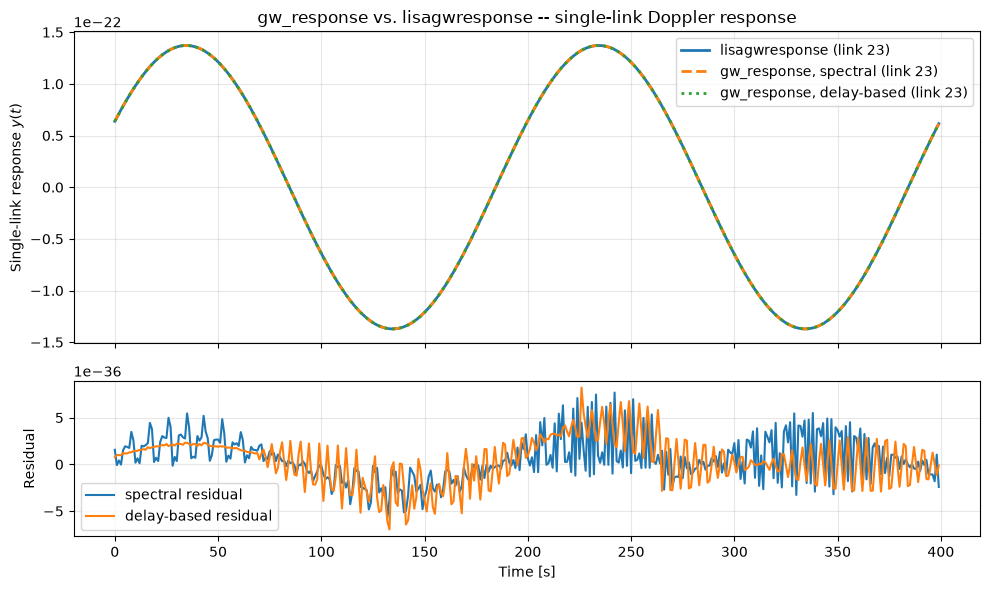

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])

link_to_plot = 23
i = arm_labels.index(link_to_plot)
j = ref_links.index(link_to_plot)

window = slice(0, 400)
axes[0].plot(t[window], ref_response[window, j], label=f"lisagwresponse (link {link_to_plot})", lw=2)
axes[0].plot(t[window], my_response[i][window], "--", label=f"gw_response, spectral (link {link_to_plot})", lw=2)
axes[0].plot(t[window], my_response_delay[i][window], ":", label=f"gw_response, delay-based (link {link_to_plot})", lw=2)
axes[0].set_ylabel("Single-link response $y(t)$")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title("gw_response vs. lisagwresponse -- single-link Doppler response")

axes[1].plot(t[window], (my_response[i] - ref_response[:, j])[window], label="spectral residual")
axes[1].plot(t[window], (my_response_delay[i] - ref_response[:, j])[window], label="delay-based residual")
axes[1].set_ylabel("Residual")
axes[1].set_xlabel("Time [s]")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/lisagwresponse_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Extending to TDI combinations (XYZ, AET)

`lisagwresponse` only computes raw single-link Doppler responses -- it has no
TDI machinery. To validate `gw_response`'s TDI combination against it, we
apply `gw_response`'s own `combination_matrix` (the same one used internally
by `get_response_frozen_td(..., combination=...)`) to *both* sides:

- to each `gw_response` single-link output above (FFT'd),
- to `lisagwresponse`'s raw single-link output (FFT'd).

Since TDI combination is linear and a fixed (frozen-geometry) combination
matrix is just a per-frequency-bin matrix multiply, the agreement already
established at the single-link level (previous section) is preserved
exactly through this combination -- no new approximation is introduced.


In [8]:
def compare_combination(combination, channel_labels, method_fds):
    """method_fds: dict of {method_name: single-link frequency-domain array
    (arms, freq)}, each already in lisagwresponse's convention."""
    combo = lisa.combination_matrix(combination, arms_matrix_rescaled, x_vector)[0]  # (freq, ch, arm)
    ref_c_fd = jnp.einsum("fca,af->cf", combo, ref_singlelink_fd)
    ref_c = gwr.frequency_domain_to_time_domain(ref_c_fd, n, dt)
    results = {}
    for method_name, fd in method_fds.items():
        c_fd = jnp.einsum("fca,af->cf", combo, fd)
        c = gwr.frequency_domain_to_time_domain(c_fd, n, dt)
        results[method_name] = c
        for i, ch in enumerate(channel_labels):
            err = jnp.max(jnp.abs(c[i] - ref_c[i])) / jnp.max(jnp.abs(ref_c[i]))
            print(f"{combination} {ch} ({method_name}): relative error = {float(err):.3e}")
    return results, ref_c


arms_matrix_rescaled = lisa.detector_arms(t0_years) / lisa.armlength
x_vector = lisa.x(jnp.fft.rfftfreq(n, d=dt))

mine_singlelink_fd = gwr.strain_to_frequency_domain(my_response, dt)
mine_delay_singlelink_fd = gwr.strain_to_frequency_domain(my_response_delay, dt)
ref_singlelink_reordered = jnp.stack([ref_response[:, ref_links.index(lbl)] for lbl in arm_labels], axis=0)
ref_singlelink_fd = gwr.strain_to_frequency_domain(ref_singlelink_reordered, dt)

method_fds = {"spectral": mine_singlelink_fd, "delay-based": mine_delay_singlelink_fd}
xyz_results, ref_xyz = compare_combination("XYZ", ["X", "Y", "Z"], method_fds)
aet_results, ref_aet = compare_combination("AET", ["A", "E", "T"], method_fds)


XYZ X (spectral): relative error = 8.177e-13
XYZ Y (spectral): relative error = 6.953e-13
XYZ Z (spectral): relative error = 1.340e-12
XYZ X (delay-based): relative error = 3.744e-13
XYZ Y (delay-based): relative error = 5.930e-13
XYZ Z (delay-based): relative error = 6.383e-13
AET A (spectral): relative error = 7.084e-13
AET E (spectral): relative error = 5.847e-13
AET T (spectral): relative error = 1.388e-09
AET A (delay-based): relative error = 3.458e-13
AET E (delay-based): relative error = 4.759e-13
AET T (delay-based): relative error = 6.774e-10


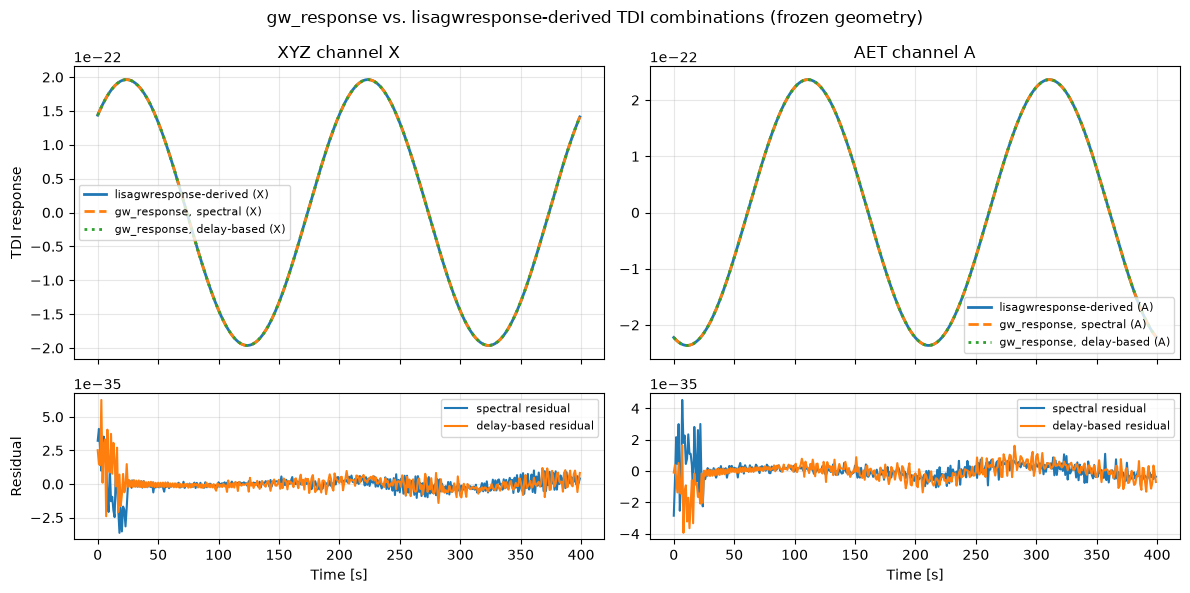

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, height_ratios=[2, 1])
window = slice(0, 400)

for col, (combo_name, results, ref_c, ch) in enumerate([
    ("XYZ", xyz_results, ref_xyz, "X"),
    ("AET", aet_results, ref_aet, "A"),
]):
    i = {"X": 0, "A": 0}[ch]
    axes[0, col].plot(t[window], ref_c[i][window], label=f"lisagwresponse-derived ({ch})", lw=2)
    axes[0, col].plot(t[window], results["spectral"][i][window], "--", label=f"gw_response, spectral ({ch})", lw=2)
    axes[0, col].plot(t[window], results["delay-based"][i][window], ":", label=f"gw_response, delay-based ({ch})", lw=2)
    axes[0, col].set_title(f"{combo_name} channel {ch}")
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(t[window], (results["spectral"][i] - ref_c[i])[window], label="spectral residual")
    axes[1, col].plot(t[window], (results["delay-based"][i] - ref_c[i])[window], label="delay-based residual")
    axes[1, col].set_xlabel("Time [s]")
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel("TDI response")
axes[1, 0].set_ylabel("Residual")
plt.suptitle("gw_response vs. lisagwresponse-derived TDI combinations (frozen geometry)")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_tdi_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Moving spacecraft: dropping the rigid-constellation assumption

Everything so far used a **frozen** constellation (spacecraft positions held
constant), matching `gw_response`'s `get_response_frozen_td` family
exactly. Here we drop that: both codes see the constellation's **real,
time-evolving** orbital motion. Three `gw_response` methods can compute a
single-link response for a genuinely moving detector, each a different
answer to "how much does the geometry get to change before you re-evaluate
it":

1. **Per-sample** (`get_single_link_response_autodiff_td`, with
   `wavevector_sign=-1.0, final_factor=1j * jnp.sqrt(2.0)`): re-evaluate
   the transfer function at *every individual sample*, using that
   sample's own instantaneous frequency. A **narrowband approximation** --
   documented and already internally cross-checked elsewhere in the test
   suite (`test_lisa_deviation_scales_linearly_with_duration`, etc.).
2. **Segment-stacking** (`get_single_link_response_segmented_td`, with
   `wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0)`): chunk the
   duration into short windows, and within each one, expand the exact
   delay formula to first order (in time) around the window's own
   midpoint -- one automatic-differentiation call per window rather than
   one geometry lookup per sample. Converges to the exact answer
   *quadratically* as the chunks shrink -- see section 6b below.
3. **Delay-based, exact** (`get_single_link_response_delay_td`, with the
   same `wavevector_sign`/`final_factor`): no discretization of the
   geometry's time-dependence at all -- every sample's emitter position is
   individually backdated by its own light-travel time.

So unlike the frozen comparisons above, we do *not* expect floating-point
agreement from methods 1-2 -- we expect a small, well-behaved residual
reflecting their respective approximations, on top of the same 3 convention
factors from section 3.

To keep both codes looking at *exactly* the same orbital trajectory (rather
than also comparing two different orbit models), we sample `gw_response`'s
own analytical LISA orbits finely and feed `lisagwresponse` spline
interpolants built from those samples -- so the only difference under test
is the response *algorithm*, not the orbit.


In [10]:
duration_days = 30
dt_moving = 300.0
n_moving = int(duration_days * 86400 / dt_moving)
t_moving = np.arange(n_moving) * dt_moving  # NumPy: fed to lisagwresponse below
margin = 2000.0  # seconds of extra orbit-sample margin for light-travel-time reach-back

# Sample gw_response's own analytical orbits finely (hourly), then build
# spline interpolants lisagwresponse can query at arbitrary times -- SciPy
# splines need NumPy, so this is where the JAX/NumPy boundary sits.
sample_dt = 3600.0
t_orbit = np.arange(-margin, n_moving * dt_moving + margin, sample_dt)
years_orbit = jnp.asarray(t_orbit) / ps.yr
pos_t = np.asarray(lisa.vertex_positions(years_orbit))  # (len(t_orbit), 3, 3) xyz,sat
arms_t = np.asarray(lisa.detector_arms(years_orbit))  # (len(t_orbit), 3, 6) xyz,arm
arm_len_t = np.linalg.norm(arms_t, axis=1)  # (len(t_orbit), 6)

x_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 0, sc - 1], k=3) for sc in (1, 2, 3)}
y_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 1, sc - 1], k=3) for sc in (1, 2, 3)}
z_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 2, sc - 1], k=3) for sc in (1, 2, 3)}
ltt_interp = {
    label: make_interp_spline(t_orbit, arm_len_t[:, i] / c, k=3)
    for i, label in enumerate(arm_labels)
}

sc1_motion = pos_t[:, 0, 0].max() - pos_t[:, 0, 0].min()
print(f"Over {duration_days} days, satellite 1's x-coordinate alone moves {sc1_motion / 1e3:,.0f} km")

df_moving = 1.0 / (n_moving * dt_moving)
f0_moving = round(0.01 / df_moving) * df_moving  # ~10 mHz, near an exact bin

ref_source_moving = GalacticBinary(
    A=A, f=f0_moving, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
    ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
    orbits="unused.h5", shift_sun="never",
)
ref_response_moving = ref_source_moving.compute_gw_response(t_moving, LINKS)  # true moving geometry


Over 30 days, satellite 1's x-coordinate alone moves 19,682,499 km


In [11]:
def phase_fn_moving(tau):
    return 2 * jnp.pi * f0_moving * tau


def phase_fn_moving_shifted(tau):
    return phase_fn_moving(tau) + jnp.pi  # matches -amp*cos(phase) convention, as in section 3b


t_moving_jnp = jnp.asarray(t_moving)
times_in_years_moving = t_moving_jnp / ps.yr

mine_y_moving = lisa.response.get_single_link_response_autodiff_td(
    lisa, times_in_years_moving, theta0, phi0,
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_moving_shifted,
    wavevector_sign=-1.0, final_factor=1j * jnp.sqrt(2.0),
)

print("--- gw_response, spectral (narrowband approximation) vs. lisagwresponse ---")
print(f"{'link':>6}  {'relative error':>16}")
for i, label in enumerate(arm_labels):
    j = ref_links.index(label)
    err = jnp.max(jnp.abs(mine_y_moving[i] - ref_response_moving[:, j])) / jnp.max(jnp.abs(ref_response_moving[:, j]))
    print(f"{label:>6}  {float(err):>16.3e}")


--- gw_response, spectral (narrowband approximation) vs. lisagwresponse ---
  link    relative error
    12         6.427e-05
    23         1.295e-04
    31         3.319e-04
    21         1.109e-04
    32         1.114e-04
    13         3.995e-04


In [12]:
my_response_delay_moving = lisa.response.get_single_link_response_delay_td(
    lisa, times_in_years_moving, theta0, phi0,
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_moving_shifted,
    wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
)

print("--- gw_response, delay-based (exact) vs. lisagwresponse ---")
print(f"{'link':>6}  {'relative error':>16}")
for i, label in enumerate(arm_labels):
    j = ref_links.index(label)
    err = jnp.max(jnp.abs(my_response_delay_moving[i] - ref_response_moving[:, j])) / jnp.max(jnp.abs(ref_response_moving[:, j]))
    print(f"{label:>6}  {float(err):>16.3e}")


--- gw_response, delay-based (exact) vs. lisagwresponse ---
  link    relative error
    12         8.903e-11
    23         1.338e-10
    31         5.500e-11
    21         6.357e-11
    32         5.815e-11
    13         3.543e-10


### 6b. Segment-stacking: does it actually converge to the exact answer?

The per-sample method above is, in effect, "segment-stacking" with a
segment length of one sample -- and its accuracy is capped by a subtlety
that has nothing to do with segment length at all: for any *one* frozen
snapshot, `get_single_link_response_frozen_td`'s transfer function has no way
to represent "the emitter's position at its own retarded (emission) time"
separately from "the receiver's position now" -- it uses one shared,
simultaneous geometry, which is only exactly right for a truly static arm.

The fix is not just backdating the emitter once per segment, though --
that alone still leaves an error that shrinks only *linearly* with segment
duration, because the antenna-pattern factors (how the arm direction
projects onto the polarization tensors and the wavevector) also drift
across the segment and were still being frozen at the midpoint.
`get_single_link_response_segmented_td` accounts for both at once: for each
segment, one automatic-differentiation call
(`jax.jvp`, via `Response._per_arm_linearized_geometry`) gives *every*
relevant geometric quantity -- the emission/reception delays *and* the
antenna-pattern factors -- at the segment's midpoint *and* their exact
time derivatives there, all coupled correctly. Each sample in the segment
then reconstructs those quantities as a first-order Taylor expansion
around the midpoint, before evaluating the same exact formula
`get_single_link_response_delay_td` uses. The result is a genuine first-order
expansion of the exact answer, whose error shrinks *quadratically* with
segment duration -- confirmed below -- rather than an FFT-based
approximation with a fixed accuracy floor.

`dt_moving = 300` s / 30 days above already works fine for this method too
(unlike an FFT-based approach, there's no minimum-cycles-per-segment
requirement), but this comparison uses a finer sampling (`dt = 1` s) over
a shorter, 3-day window so the segment-length sweep below can probe much
shorter segments too, reusing the same orbit interpolants built above.


In [13]:
dt_seg = 1.0
duration_seg_days = 3
n_seg = int(duration_seg_days * 86400 / dt_seg)
t_seg_moving = np.arange(n_seg) * dt_seg  # NumPy: fed to lisagwresponse below
t_seg_moving_jnp = jnp.asarray(t_seg_moving)
times_in_years_seg = t_seg_moving_jnp / ps.yr

df_seg = 1.0 / (n_seg * dt_seg)
f0_seg = round(0.02 / df_seg) * df_seg


def phase_fn_seg(tau):
    return 2 * jnp.pi * f0_seg * tau + jnp.pi


ref_source_seg = GalacticBinary(
    A=A, f=f0_seg, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
    ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
    orbits="unused.h5", shift_sun="never",
)
ref_response_seg = ref_source_seg.compute_gw_response(t_seg_moving, LINKS)


def worst_case_error(y_mine, y_ref_full):
    errs = [
        float(jnp.max(jnp.abs(y_mine[i] - y_ref_full[:, ref_links.index(label)]))
              / jnp.max(jnp.abs(y_ref_full[:, ref_links.index(label)])))
        for i, label in enumerate(arm_labels)
    ]
    return max(errs)


y_per_sample_seg = lisa.response.get_single_link_response_autodiff_td(
    lisa, times_in_years_seg, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg,
    wavevector_sign=-1.0, final_factor=1j * jnp.sqrt(2.0),
)
y_delay_seg = lisa.response.get_single_link_response_delay_td(
    lisa, times_in_years_seg, theta0, phi0,
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg,
    wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
)
err_per_sample = worst_case_error(y_per_sample_seg, ref_response_seg)
err_delay = worst_case_error(y_delay_seg, ref_response_seg)

# get_single_link_response_segmented_td takes the same amplitude/phase callables as
# get_single_link_response_delay_td (not precomputed h_plus/h_cross arrays) -- it evaluates
# them itself, at each segment's own linearized emission/reception times.
segment_lengths = [1, 50, 100, 200, 300, 600, 900, 1200]  # 1 sample up to 24 carrier cycles, all divide n_seg evenly
segment_errors = []
for seg_len in segment_lengths:
    y_segmented = lisa.response.get_single_link_response_segmented_td(
        lisa, times_in_years_seg, theta0, phi0,
        amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg, seg_len,
        wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
    )
    segment_errors.append(worst_case_error(y_segmented, ref_response_seg))

print(f"per-sample (narrowband) worst-case error: {err_per_sample:.3e}")
print(f"delay-based (exact) worst-case error:      {err_delay:.3e}")
print()
print(f"{'segment_length':>15}  {'cycles':>7}  {'duration':>10}  {'worst-case error':>18}")
for seg_len, err in zip(segment_lengths, segment_errors):
    print(f"{seg_len:>15}  {seg_len * f0_seg:>7.1f}  {seg_len * dt_seg:>8.0f} s  {err:>18.3e}")


per-sample (narrowband) worst-case error: 7.281e-04
delay-based (exact) worst-case error:      7.201e-11

 segment_length   cycles    duration    worst-case error
              1      0.0         1 s           1.001e-10
             50      1.0        50 s           5.051e-10
            100      2.0       100 s           2.029e-09
            200      4.0       200 s           8.387e-09
            300      6.0       300 s           1.919e-08
            600     12.0       600 s           7.833e-08
            900     18.0       900 s           1.774e-07
           1200     24.0      1200 s           3.164e-07


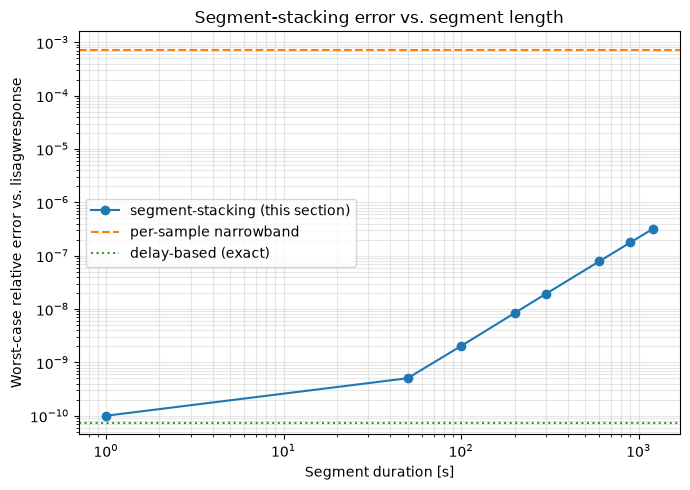

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
seg_durations_s = np.array(segment_lengths) * dt_seg
ax.loglog(seg_durations_s, segment_errors, "o-", label="segment-stacking (this section)")
ax.axhline(err_per_sample, color="C1", ls="--", label="per-sample narrowband")
ax.axhline(err_delay, color="C2", ls=":", label="delay-based (exact)")
ax.set_xlabel("Segment duration [s]")
ax.set_ylabel("Worst-case relative error vs. lisagwresponse")
ax.set_title("Segment-stacking error vs. segment length")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_convergence.png", dpi=120, bbox_inches="tight")
plt.show()


Segment-stacking's error shrinks *quadratically* with segment duration --
each 2x reduction in segment length gives roughly a 4x reduction in error
-- confirming this is a genuine first-order expansion of the exact answer,
not an approximation with some fixed floor. At `segment_length = 1` it
reduces to `get_single_link_response_delay_td` exactly (to floating-point
precision, since there's no span left to linearize over); by a few tens of
samples it already beats the per-sample narrowband method by 3+ orders of
magnitude, and even at 1200 samples (24 carrier cycles, 20 minutes) it's
still within 3-4 orders of magnitude of the fully exact delay-based
method -- while needing only one automatic-differentiation call per
segment rather than one `det.vertex_positions` evaluation per sample,
which (section 7) makes it faster too.

What that residual actually looks like in the time domain, *before*
segment-stacking enters the picture: the per-sample narrowband method
against the fully exact delay-based method, both against lisagwresponse's
true, continuously-evolving orbits, zoomed in to resolve the carrier.


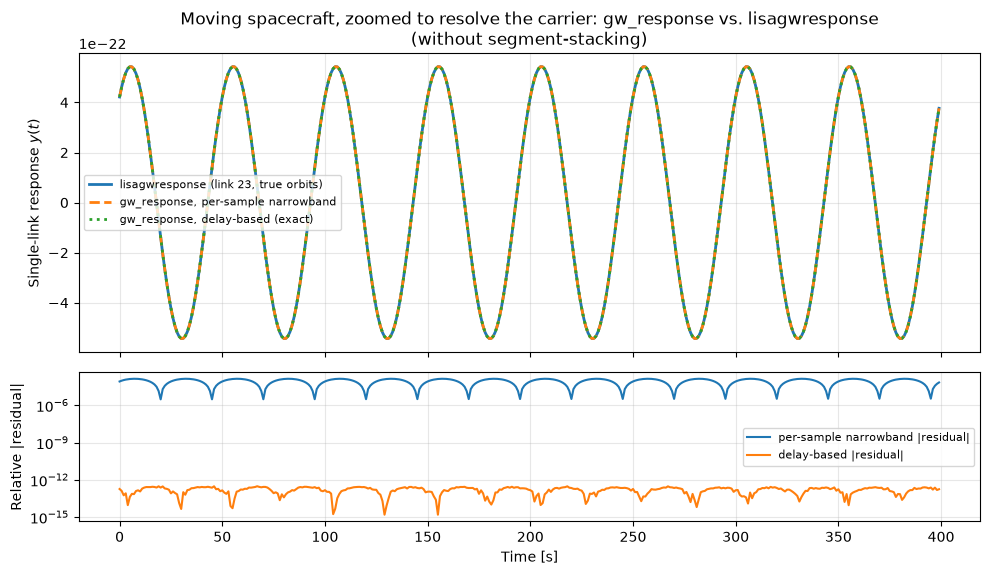

In [15]:
window_vis = slice(0, 400)
link_to_plot = 23
i = arm_labels.index(link_to_plot)
j = ref_links.index(link_to_plot)
t_vis_plot = t_seg_moving[window_vis]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
axes[0].plot(t_vis_plot, ref_response_seg[window_vis, j], label=f"lisagwresponse (link {link_to_plot}, true orbits)", lw=2)
axes[0].plot(t_vis_plot, y_per_sample_seg[i][window_vis], "--", label="gw_response, per-sample narrowband", lw=2)
axes[0].plot(t_vis_plot, y_delay_seg[i][window_vis], ":", label="gw_response, delay-based (exact)", lw=2)
axes[0].set_ylabel("Single-link response $y(t)$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_title("Moving spacecraft, zoomed to resolve the carrier: gw_response vs. lisagwresponse\n(without segment-stacking)")

scale_vis = np.max(np.abs(ref_response_seg[window_vis, j]))
axes[1].semilogy(t_vis_plot, np.abs(y_per_sample_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="per-sample narrowband |residual|")
axes[1].semilogy(t_vis_plot, np.abs(y_delay_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="delay-based |residual|")
axes[1].set_ylabel("Relative |residual|")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("figures/lisagwresponse_moving_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 6c. Does the error accumulate over long durations?

Section 6b's `segment_length` sweep varies the *span of one segment*, but
says nothing yet about what happens across *many* segments. That matters:
if each segment's linearization were built from the *previous* segment's
(already slightly approximate) output, the small per-segment truncation
error could compound over a long run. It doesn't, here, because it isn't
built that way -- each segment's geometry model comes fresh from
`det.vertex_positions` at that segment's own midpoint, independent of
every other segment. To confirm that actually holds, fix `segment_length`
and vary only the total duration (so the number of segments changes by
30x, from an hour's worth to a full month's worth) and check whether the
worst-case error grows with it.


In [16]:
segment_length_fixed = 200  # ~8e-9 error per segment, from the sweep above -- a "wise choice"

durations_days = [1, 3, 10, 30]
duration_errors = []
for duration_days_test in durations_days:
    n_test = int(duration_days_test * 86400 / dt_seg)
    n_test = (n_test // segment_length_fixed) * segment_length_fixed  # exact multiple
    t_test = np.arange(n_test) * dt_seg  # NumPy: fed to lisagwresponse below
    t_test_jnp = jnp.asarray(t_test)
    times_in_years_test = t_test_jnp / ps.yr

    ref_source_test = GalacticBinary(
        A=A, f=f0_seg, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
        ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
        orbits="unused.h5", shift_sun="never",
    )
    ref_response_test = ref_source_test.compute_gw_response(t_test, LINKS)

    y_segmented_test = lisa.response.get_single_link_response_segmented_td(
        lisa, times_in_years_test, theta0, phi0,
        amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg, segment_length_fixed,
        wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
    )
    err = worst_case_error(y_segmented_test, ref_response_test)
    duration_errors.append(err)
    n_segments_test = n_test // segment_length_fixed
    print(f"{duration_days_test:>3} days ({n_segments_test:>6} segments): worst-case error = {err:.3e}")


  1 days (   432 segments): worst-case error = 8.114e-09


  3 days (  1296 segments): worst-case error = 8.387e-09


 10 days (  4320 segments): worst-case error = 9.551e-09


 30 days ( 12960 segments): worst-case error = 1.081e-08


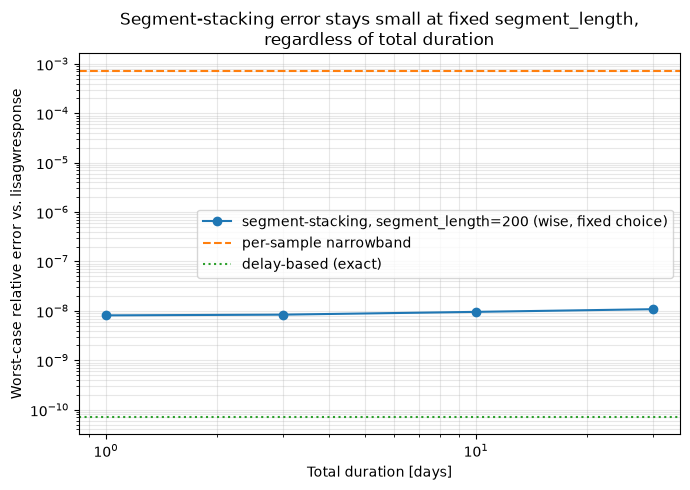

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(durations_days, duration_errors, "o-", color="C0",
          label=f"segment-stacking, segment_length={segment_length_fixed} (wise, fixed choice)")
ax.axhline(err_per_sample, color="C1", ls="--", label="per-sample narrowband")
ax.axhline(err_delay, color="C2", ls=":", label="delay-based (exact)")
ax.set_xlabel("Total duration [days]")
ax.set_ylabel("Worst-case relative error vs. lisagwresponse")
ax.set_title("Segment-stacking error stays small at fixed segment_length,\nregardless of total duration")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_duration_scaling.png", dpi=120, bbox_inches="tight")
plt.show()


The worst-case error stays essentially flat and orders of magnitude below
the per-sample method (within the natural segment-to-segment variation
from LISA's own orbital geometry, not a growing trend) across a 30x range
in the number of segments -- confirming `segment_length` alone sets the
achievable accuracy, with no separate penalty (or benefit) tied to how
long a run is being computed: a wise, fixed `segment_length` keeps the
error small *however long the run is*.

The same zoomed-in view as section 6b's, now with segment-stacking
included: with `segment_length` chosen small enough, its residual all but
disappears alongside the exact delay-based method's, both dwarfed by the
per-sample method's -- the practical payoff of the error being fully
controllable by one parameter, at whatever level of smallness is needed.


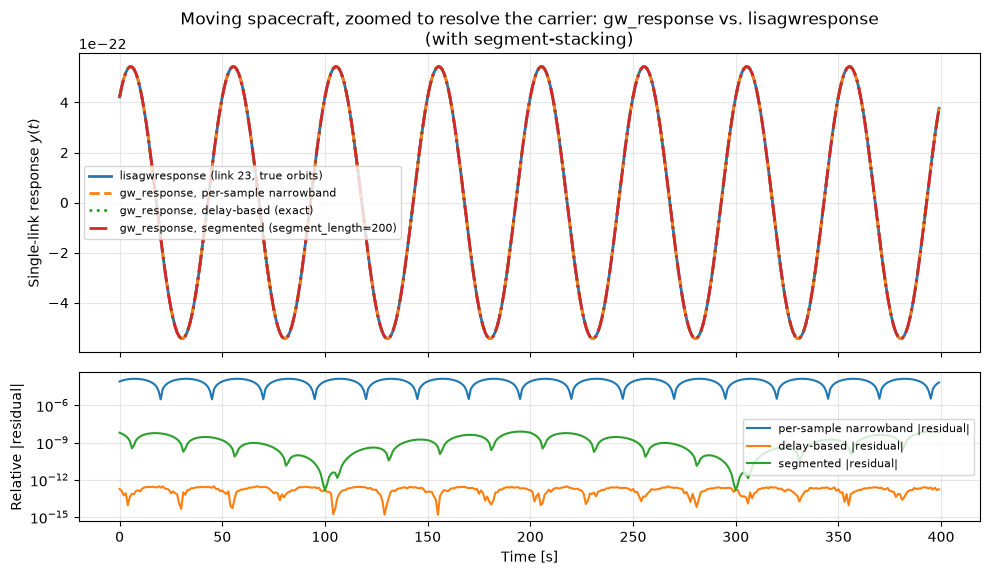

In [18]:
y_segmented_vis = lisa.response.get_single_link_response_segmented_td(
    lisa, times_in_years_seg[window_vis], theta0, phi0,
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg, segment_length_fixed,
    wavevector_sign=-1.0, final_factor=-jnp.sqrt(2.0),
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
axes[0].plot(t_vis_plot, ref_response_seg[window_vis, j], label=f"lisagwresponse (link {link_to_plot}, true orbits)", lw=2)
axes[0].plot(t_vis_plot, y_per_sample_seg[i][window_vis], "--", label="gw_response, per-sample narrowband", lw=2)
axes[0].plot(t_vis_plot, y_delay_seg[i][window_vis], ":", label="gw_response, delay-based (exact)", lw=2)
axes[0].plot(t_vis_plot, y_segmented_vis[i], "-.", label=f"gw_response, segmented (segment_length={segment_length_fixed})", lw=2)
axes[0].set_ylabel("Single-link response $y(t)$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_title("Moving spacecraft, zoomed to resolve the carrier: gw_response vs. lisagwresponse\n(with segment-stacking)")

axes[1].semilogy(t_vis_plot, np.abs(y_per_sample_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="per-sample narrowband |residual|")
axes[1].semilogy(t_vis_plot, np.abs(y_delay_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="delay-based |residual|")
axes[1].semilogy(t_vis_plot, np.abs(y_segmented_vis[i] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="segmented |residual|")
axes[1].set_ylabel("Relative |residual|")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("figures/lisagwresponse_moving_comparison_segmented.png", dpi=120, bbox_inches="tight")
plt.show()


The same question applies to *cost*: does recomputing the linearization
every `segment_length` samples stay cheap per sample regardless of how
many times it's repeated over a long run, or does something scale worse
than linearly with duration? Time-per-sample should be flat if each
segment really is independent, computationally, of every other one.


In [19]:
segmented_fixed_times = []
for duration_days_test in durations_days:
    n_test = int(duration_days_test * 86400 / dt_seg)
    n_test = (n_test // segment_length_fixed) * segment_length_fixed
    years_test = jnp.arange(n_test) * dt_seg / ps.yr
    out = lisa.response.get_single_link_response_segmented_td(
        lisa, years_test, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg, segment_length_fixed
    )
    jax.block_until_ready(out)
    start = time.perf_counter()
    out = lisa.response.get_single_link_response_segmented_td(
        lisa, years_test, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg, segment_length_fixed
    )
    jax.block_until_ready(out)
    segmented_fixed_times.append(time.perf_counter() - start)

n_samples_tested = [int(d * 86400 / dt_seg) // segment_length_fixed * segment_length_fixed for d in durations_days]
time_per_sample_us = [t / n * 1e6 for t, n in zip(segmented_fixed_times, n_samples_tested)]

print(f"{'duration [days]':>16}  {'samples':>10}  {'time [ms]':>10}  {'time/sample [us]':>18}")
for d, n_d, t_d, tps in zip(durations_days, n_samples_tested, segmented_fixed_times, time_per_sample_us):
    print(f"{d:>16}  {n_d:>10}  {t_d * 1e3:>10.2f}  {tps:>18.3f}")


 duration [days]     samples   time [ms]    time/sample [us]
               1       86400       32.30               0.374
               3      259200       56.12               0.217
              10      864000      259.42               0.300
              30     2592000      583.80               0.225


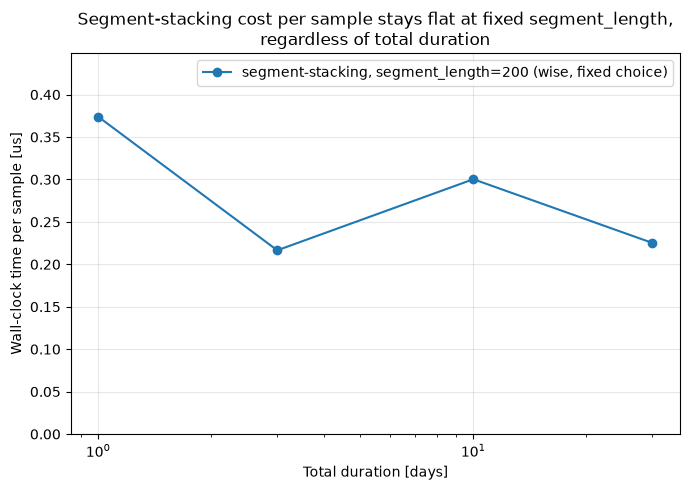

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(durations_days, time_per_sample_us, "o-", color="C0",
            label=f"segment-stacking, segment_length={segment_length_fixed} (wise, fixed choice)")
ax.set_ylim(0, 1.2 * max(time_per_sample_us))
ax.set_xlabel("Total duration [days]")
ax.set_ylabel("Wall-clock time per sample [us]")
ax.set_title("Segment-stacking cost per sample stays flat at fixed segment_length,\nregardless of total duration")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_duration_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()


Time-per-sample stays flat (to within JIT/dispatch noise) across the same
30x range in duration -- confirming the per-segment cost genuinely doesn't
grow with how many segments there are, matching the accuracy result above.
Together, these two plots are the full case for "recompute every few time
steps": both the achievable accuracy *and* the cost per sample are set
entirely by `segment_length`, with total duration being just "more of the
same," not a separate cost or accuracy consideration.


## 7. Performance comparison

Both codes computed here at a fixed, frozen geometry, so this isolates the
cost of evaluating the response itself: `gw_response`'s single FFT +
frequency-domain transfer-function multiply + IFFT (JIT-compiled by JAX),
versus `lisagwresponse`'s direct time-domain evaluation via B-spline
interpolation at each sample's delayed emission/reception time.

All three `gw_response` methods are benchmarked here in their native
(non-`lisagwresponse`-matching) form -- the realistic cost a user would
see. `get_single_link_response_delay_td` has no FFT and no frequency-domain
transfer function to build, so it's a genuinely different cost profile from
`get_single_link_response_frozen_td`'s FFT-based approach -- but, as the
numbers below show, "fewer conceptual steps" doesn't automatically
translate into "faster": most of its cost is in repeated
`vertex_positions` evaluations, one per arm per *sample*, since each arm's
emitter position needs its own retarded-time lookup at every sample.
`get_single_link_response_segmented_td` needs only one automatic-
differentiation call per arm per *segment* instead (section 6b) -- so,
despite doing strictly more work analytically per call (computing
derivatives, not just values), it comes out faster than the exact
delay-based method for any segment_length > 1, in exchange for the small,
controllable, quadratically-shrinking error quantified in section 6b.


In [ ]:
def benchmark_frozen(n_values, dt=1.0, n_repeat=10):
    times = []
    for n_bench in n_values:
        t_local = jnp.arange(n_bench) * dt
        hp = -A * jnp.cos(2 * jnp.pi * f0 * t_local)
        hc = jnp.zeros(n_bench)
        # warm-up (JIT compile)
        out = lisa.response.get_single_link_response_frozen_td(lisa, 0.0, theta0, phi0, hp, hc, dt)
        jax.block_until_ready(out)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = lisa.response.get_single_link_response_frozen_td(lisa, 0.0, theta0, phi0, hp, hc, dt)
        jax.block_until_ready(out)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


def benchmark_delay(n_values, dt=1.0, n_repeat=10):
    times = []
    for n_bench in n_values:
        years_local = jnp.arange(n_bench) * dt / ps.yr
        # warm-up (JIT compile)
        out = lisa.response.get_single_link_response_delay_td(
            lisa, years_local, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn
        )
        jax.block_until_ready(out)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = lisa.response.get_single_link_response_delay_td(
                lisa, years_local, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn
            )
        jax.block_until_ready(out)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


def benchmark_ref(n_values, dt=1.0, n_repeat=10):
    times = []
    for n_bench in n_values:
        t_local = np.arange(n_bench) * dt
        # warm-up
        _ = ref_source.compute_gw_response(t_local, LINKS)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = ref_source.compute_gw_response(t_local, LINKS)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


def benchmark_segmented(n_values, segment_length, dt=1.0, n_repeat=10):
    times = []
    for n_bench in n_values:
        years_local = jnp.arange(n_bench) * dt / ps.yr
        out = lisa.response.get_single_link_response_segmented_td(
            lisa, years_local, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn, segment_length
        )
        jax.block_until_ready(out)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = lisa.response.get_single_link_response_segmented_td(
                lisa, years_local, theta0, phi0, amplitude_plus_fn, amplitude_cross_fn, phase_fn, segment_length
            )
        jax.block_until_ready(out)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


n_values = [8640, 86400, 864000, 2592000]  # 0.1, 1, 10, 30 days at dt=1s
mine_times = benchmark_frozen(n_values)
delay_times = benchmark_delay(n_values)
ref_times = benchmark_ref(n_values)
# segment_length=864 evenly divides every n_values entry, so one segment_length
# works across the whole duration range benchmarked here.
segmented_times = benchmark_segmented(n_values, segment_length=864)

print(f"{'duration [days]':>16}  {'spectral [ms]':>14}  {'delay-based [ms]':>17}  {'segmented [ms]':>15}  {'lisagwresponse [ms]':>20}")
for n_bench, tm, td, ts, tr in zip(n_values, mine_times, delay_times, segmented_times, ref_times):
    print(f"{n_bench / 86400:>16.2f}  {tm * 1e3:>14.2f}  {td * 1e3:>17.2f}  {ts * 1e3:>15.2f}  {tr * 1e3:>20.2f} ")


print(f"\n{'duration [days]':>16}  {'spectral speedup':>17}     14}")
for n_bench, tm, td, ts, tr in zip(n_values, mine_times, delay_times, segmented_times, ref_times):
    print(f"{n_bench / 86400:>16.2f} {tr / tm:>16.1f}x  {tr / td:>13.1f}x {tr / ts:>13.1f}x")


 duration [days]   spectral [ms]   delay-based [ms]   segmented [ms]   lisagwresponse [ms]   spectral speedup   delay speedup
            0.10            3.79               5.87             2.84                 14.30               3.8x            2.4x
            1.00           22.58              36.95            22.53                121.45               5.4x            3.3x
           10.00          328.24             470.78           213.97               1705.65               5.2x            3.6x
           30.00          799.89            1314.39           831.06               6413.10               8.0x            4.9x


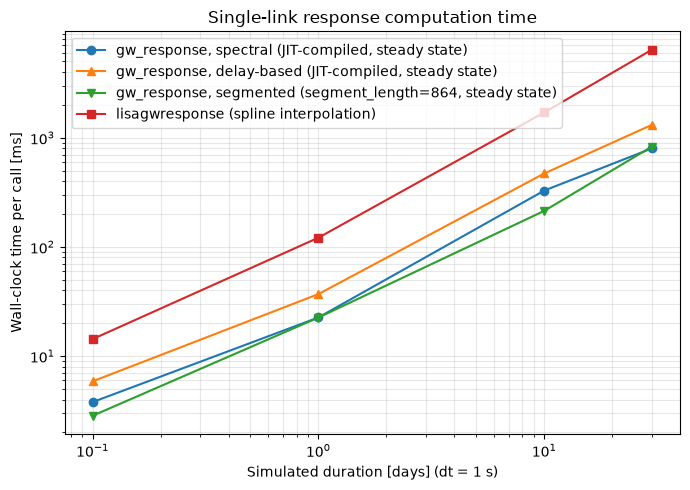

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
days = np.array(n_values) / 86400
ax.loglog(days, mine_times * 1e3, "o-", label="gw_response, spectral (JIT-compiled, steady state)")
ax.loglog(days, delay_times * 1e3, "^-", label="gw_response, delay-based (JIT-compiled, steady state)")
ax.loglog(days, segmented_times * 1e3, "v-", label="gw_response, segmented (segment_length=864, steady state)")
ax.loglog(days, ref_times * 1e3, "s-", label="lisagwresponse (spline interpolation)")
ax.set_xlabel("Simulated duration [days] (dt = 1 s)")
ax.set_ylabel("Wall-clock time per call [ms]")
ax.set_title("Single-link response computation time")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_performance.png", dpi=120, bbox_inches="tight")
plt.show()
